# SF$_6$-like - calculate observational network global- annual-mean, latitudinal gradient and seasonality

Calculate global-mean, latitudinal gradient and seasonality
based on the observational network.
We also perform an EOF analysis for the latitudinal gradient.
We also perform an EOF analysis for the seasonality change.

## Imports

In [1]:
from pathlib import Path

import cf_xarray.units
import matplotlib.axes
import matplotlib.pyplot as plt
import pint_xarray
import xarray as xr
from pydoit_nb.config_handling import get_config_for_step_id

import local.binned_data_interpolation
import local.binning
import local.latitudinal_gradient
import local.mean_preserving_interpolation
import local.raw_data_processing
import local.seasonality
import local.xarray_space
import local.xarray_time
from local.config import load_config_from_file

In [2]:
cf_xarray.units.units.define("ppm = 1 / 1000000")
cf_xarray.units.units.define("ppb = ppm / 1000")
cf_xarray.units.units.define("ppt = ppb / 1000")

pint_xarray.accessors.default_registry = pint_xarray.setup_registry(cf_xarray.units.units)

## Define branch this notebook belongs to

In [3]:
step: str = "calculate_sf6_like_monthly_fifteen_degree_pieces"

## Parameters

In [4]:
config_file: str = "../../dev-config-absolute.yaml"  # config file
step_config_id: str = "ch2cl2"  # config ID to select for this branch

In [5]:
# Parameters
config_file = "/Users/znicholls/Documents/repos/CMIP-GHG-Concentration-Generation/output-bundles/v1.0.0/v1.0.0-config.yaml"
step_config_id = "halon1301"


## Load config

In [6]:
config = load_config_from_file(Path(config_file))
config_step = get_config_for_step_id(config=config, step=step, step_config_id=step_config_id)

## Action

### Load data

In [7]:
interpolated_spatial: xr.DataArray = xr.load_dataarray(  # type: ignore
    config_step.observational_network_interpolated_file
).pint.quantify()
interpolated_spatial

Magnitude,[[[2.938 2.938 2.938 ... 2.9904444444444445 2.9799999999999995 2.9120000000000004] [2.938 2.938 2.938 ... 3.019222222222222 2.98 2.912] [2.938 2.938 2.938 ... 3.048 2.9799999999999995 2.9119999999999995] [2.938 2.938 2.938 ... 3.0120000000000005 2.9619999999999997 2.912] [2.938 2.938 2.938 ... 2.932888888888889 2.9368333333333334 2.912] [2.938 2.938 2.938 ... 2.961666666666667 2.965611111111111 2.912]] [[2.925 2.925 2.925 ... 3.0008888888888894 2.9974999999999996 2.946] [2.925 2.925 2.925 ... 3.0249444444444444 2.9974999999999996 2.946] [2.925 2.925 2.925 ... 3.049 2.9975 2.946] [2.925 2.925 2.925 ... 3.0010000000000003 2.9735 2.946] [2.925 2.925 2.925 ... 2.9527777777777775 2.961416666666667 2.946] [2.925 2.925 2.925 ... 2.9768333333333334 2.9854722222222225 2.946]] [[2.968 2.968 2.968 ... 2.969333333333333 2.9629999999999996 2.937] [2.968 2.968 2.968 ... 2.9791666666666665 2.9629999999999996 2.937] [2.968 2.968 2.968 ... 2.9889999999999994 2.963 2.937] [2.968 2.968 2.968 ... 3.001 2.969 2.937] [2.968 2.968 2.968 ... 2.9496666666666664 2.94825 2.937] [2.968 2.968 2.968 ... 2.9595 2.958083333333333 2.937]] ... [[3.369 3.369 3.369 ... 3.3760000000000003 3.37 3.364] [3.369 3.369 3.369 ... 3.376 3.37 3.364] [3.369 3.369 3.369 ... 3.408 3.37 3.364] [3.369 3.369 3.369 ... 3.4033333333333338 3.3836666666666666 3.364] [3.369 3.369 3.369 ... 3.389666666666667 3.37 3.364] [3.369 3.369 3.369 ... 3.376 3.37 3.364]] [[3.373 3.373 3.373 ... 3.3813333333333335 3.373666666666667 3.366] [3.373 3.373 3.373 ... 3.3813333333333335 3.373666666666667 3.366] [3.373 3.373 3.373 ... 3.416 3.373666666666667 3.366] [3.373 3.373 3.373 ... 3.397 3.3815 3.366] [3.373 3.373 3.373 ... 3.3891666666666667 3.3736666666666664 3.366] [3.373 3.373 3.373 ... 3.381333333333333 3.373666666666667 3.366]] [[3.376 3.376 3.376 ... 3.385333333333333 3.3796666666666666 3.374] [3.376 3.376 3.376 ... 3.385333333333333 3.3796666666666666 3.374] [3.376 3.376 3.376 ... 3.3834999999999997 3.3796666666666666 3.374] [3.376 3.376 3.376 ... 3.409333333333333 3.3916666666666666 3.374] [3.376 3.376 3.376 ... 3.397333333333333 3.3796666666666666 3.374] [3.376 3.376 3.376 ... 3.385333333333333 3.3796666666666666 3.374]]]
Units,ppt


In [8]:
if config_step.year_drop_observational_data_before_and_including is not None:
    interpolated_spatial = interpolated_spatial.sel(
        time=interpolated_spatial["time"].dt.year
        > config_step.year_drop_observational_data_before_and_including
    )

if config_step.year_drop_observational_data_after_and_including is not None:
    interpolated_spatial = interpolated_spatial.sel(
        time=interpolated_spatial["time"].dt.year
        < config_step.year_drop_observational_data_after_and_including
    )

interpolated_spatial

Magnitude,[[[2.938 2.938 2.938 ... 2.9904444444444445 2.9799999999999995 2.9120000000000004] [2.938 2.938 2.938 ... 3.019222222222222 2.98 2.912] [2.938 2.938 2.938 ... 3.048 2.9799999999999995 2.9119999999999995] [2.938 2.938 2.938 ... 3.0120000000000005 2.9619999999999997 2.912] [2.938 2.938 2.938 ... 2.932888888888889 2.9368333333333334 2.912] [2.938 2.938 2.938 ... 2.961666666666667 2.965611111111111 2.912]] [[2.925 2.925 2.925 ... 3.0008888888888894 2.9974999999999996 2.946] [2.925 2.925 2.925 ... 3.0249444444444444 2.9974999999999996 2.946] [2.925 2.925 2.925 ... 3.049 2.9975 2.946] [2.925 2.925 2.925 ... 3.0010000000000003 2.9735 2.946] [2.925 2.925 2.925 ... 2.9527777777777775 2.961416666666667 2.946] [2.925 2.925 2.925 ... 2.9768333333333334 2.9854722222222225 2.946]] [[2.968 2.968 2.968 ... 2.969333333333333 2.9629999999999996 2.937] [2.968 2.968 2.968 ... 2.9791666666666665 2.9629999999999996 2.937] [2.968 2.968 2.968 ... 2.9889999999999994 2.963 2.937] [2.968 2.968 2.968 ... 3.001 2.969 2.937] [2.968 2.968 2.968 ... 2.9496666666666664 2.94825 2.937] [2.968 2.968 2.968 ... 2.9595 2.958083333333333 2.937]] ... [[3.369 3.369 3.369 ... 3.3760000000000003 3.37 3.364] [3.369 3.369 3.369 ... 3.376 3.37 3.364] [3.369 3.369 3.369 ... 3.408 3.37 3.364] [3.369 3.369 3.369 ... 3.4033333333333338 3.3836666666666666 3.364] [3.369 3.369 3.369 ... 3.389666666666667 3.37 3.364] [3.369 3.369 3.369 ... 3.376 3.37 3.364]] [[3.373 3.373 3.373 ... 3.3813333333333335 3.373666666666667 3.366] [3.373 3.373 3.373 ... 3.3813333333333335 3.373666666666667 3.366] [3.373 3.373 3.373 ... 3.416 3.373666666666667 3.366] [3.373 3.373 3.373 ... 3.397 3.3815 3.366] [3.373 3.373 3.373 ... 3.3891666666666667 3.3736666666666664 3.366] [3.373 3.373 3.373 ... 3.381333333333333 3.373666666666667 3.366]] [[3.376 3.376 3.376 ... 3.385333333333333 3.3796666666666666 3.374] [3.376 3.376 3.376 ... 3.385333333333333 3.3796666666666666 3.374] [3.376 3.376 3.376 ... 3.3834999999999997 3.3796666666666666 3.374] [3.376 3.376 3.376 ... 3.409333333333333 3.3916666666666666 3.374] [3.376 3.376 3.376 ... 3.397333333333333 3.3796666666666666 3.374] [3.376 3.376 3.376 ... 3.385333333333333 3.3796666666666666 3.374]]]
Units,ppt


### Drop out any years that have nan

These break everything later on

In [9]:
interpolated_spatial_no_year_with_nan = local.xarray_time.convert_time_to_year_month(
    interpolated_spatial
).dropna("year")
if interpolated_spatial_no_year_with_nan["year"].shape[0] != (
    interpolated_spatial_no_year_with_nan["year"].max()
    - interpolated_spatial_no_year_with_nan["year"].min()
    + 1
):
    msg = f"Missing years, this will not end well {interpolated_spatial_no_year_with_nan['year'].values=}"
    raise AssertionError(msg)

interpolated_spatial_no_year_with_nan

<xarray.DataArray 'halon1301' (lon: 6, lat: 12, year: 20, month: 12)> Size: 138kB
<Quantity([[[[2.959      3.         2.955      ... 3.03       3.
    3.01      ]
   [3.06       2.98       2.98       ... 3.01       3.01
    3.06      ]
   [3.04       3.03       3.05       ... 3.05       3.04
    3.12      ]
   ...
   [3.255      3.26375    3.268      ... 3.31533333 3.292
    3.288     ]
   [3.309      3.357      3.353      ... 3.346      3.343
    3.349     ]
   [3.347      3.343      3.359      ... 3.369      3.373
    3.376     ]]

  [[2.959      2.99116667 2.955      ... 3.03       3.01544444
    3.02655556]
   [3.04866667 2.9915     2.99766667 ... 3.029      3.03066667
    3.05766667]
   [3.05183333 3.049      3.053      ... 3.06666667 3.05433333
    3.10433333]
...
   [3.35858333 3.348      3.36111111 ... 3.40594444 3.37266667
    3.352     ]
   [3.40566667 3.415      3.40733333 ... 3.41466667 3.399
    3.40066667]
   [3.41633333 3.41533333 3.40733333 ... 3.37       3.37366667
    3.37966667]]

  [[3.152      3.195      3.201      ... 3.129      3.12
    3.125     ]
   [3.115      3.155      3.19       ... 3.236      3.186
    3.14      ]
   [3.19       3.201      3.293      ... 3.19       3.206
    3.161     ]
   ...
   [3.363      3.35825    3.371      ... 3.36575    3.413
    3.37483333]
   [3.406      3.415      3.403      ... 3.413      3.388
    3.392     ]
   [3.414      3.413      3.4        ... 3.364      3.366
    3.374     ]]]], 'ppt')>
Coordinates:
  * year     (year) int64 160B 2004 2005 2006 2007 2008 ... 2020 2021 2022 2023
  * month    (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
  * lat      (lat) float64 96B -82.5 -67.5 -52.5 -37.5 ... 37.5 52.5 67.5 82.5
  * lon      (lon) float64 48B -150.0 -90.0 -30.0 30.0 90.0 150.0
Attributes:
    description:  Interpolated spatial data

In [10]:
interpolated_spatial_nan_free = local.xarray_time.convert_year_month_to_time(
    interpolated_spatial_no_year_with_nan
)
interpolated_spatial_nan_free

Magnitude,[[[2.959 3.0 2.955 ... 3.369 3.373 3.376] [2.959 2.991166666666667 2.955 ... 3.369 3.373 3.376] [2.959 2.982333333333334 2.955 ... 3.369 3.373 3.376] ... [3.0986111111111114 3.08 3.0975 ... 3.3760000000000003 3.3813333333333335 3.385333333333333] [3.1232499999999996 3.11 3.095 ... 3.37 3.373666666666667 3.3796666666666666] [3.152 3.195 3.201 ... 3.364 3.366 3.374]] [[2.959 3.0 2.955 ... 3.369 3.373 3.376] [2.959 2.9911666666666665 2.955 ... 3.369 3.373 3.376] [2.959 2.9928260869565215 2.955 ... 3.369 3.373 3.376] ... [3.0965555555555553 3.09625 3.12525 ... 3.376 3.3813333333333335 3.385333333333333] [3.1232499999999996 3.1275 3.1278 ... 3.37 3.373666666666667 3.3796666666666666] [3.152 3.195 3.201 ... 3.364 3.366 3.374]] [[2.959 3.0 2.955 ... 3.369 3.373 3.376] [2.959 2.996413043478261 2.955 ... 3.369 3.373 3.376] [2.959 3.0085652173913044 2.955 ... 3.369 3.373 3.376] ... [3.0945 3.1125 3.1529999999999996 ... 3.408 3.416 3.3834999999999997] [3.1232499999999996 3.145 3.1606 ... 3.37 3.373666666666667 3.3796666666666666] [3.1519999999999997 3.195 3.201 ... 3.364 3.366 3.374]] [[2.959 3.0 2.955 ... 3.369 3.373 3.376] [2.959 3.0164444444444447 2.955 ... 3.369 3.373 3.376] [2.959 3.032888888888889 2.955 ... 3.369 3.373 3.376] ... [2.9920000000000004 3.148 3.105 ... 3.4033333333333338 3.397 3.409333333333333] [3.072 3.1715 3.153 ... 3.3836666666666666 3.3815 3.3916666666666666] [3.152 3.195 3.201 ... 3.364 3.366 3.374]] [[2.959 3.0 2.955 ... 3.369 3.373 3.376] [2.959 2.9911666666666665 2.955 ... 3.369 3.373 3.376] [2.959 2.994972222222222 2.955 ... 3.369 3.373 3.376] ... [3.1027222222222224 3.1253333333333333 3.1024999999999996 ... 3.389666666666667 3.3891666666666667 3.397333333333333] [3.1263333333333336 3.151 3.133666666666667 ... 3.37 3.3736666666666664 3.3796666666666666] [3.152 3.195 3.201 ... 3.364 3.366 3.374]] [[2.959 3.0 2.955 ... 3.369 3.373 3.376] [2.959 2.9911666666666665 2.955 ... 3.369 3.373 3.376] [2.959 2.982333333333333 2.955 ... 3.369 3.373 3.376] ... [3.1006666666666667 3.1026666666666665 3.1 ... 3.376 3.381333333333333 3.385333333333333] [3.124277777777778 3.1304999999999996 3.1143333333333336 ... 3.37 3.373666666666667 3.3796666666666666] [3.152 3.195 3.201 ... 3.364 3.366 3.374]]]
Units,ppt


### Longitudinal-mean

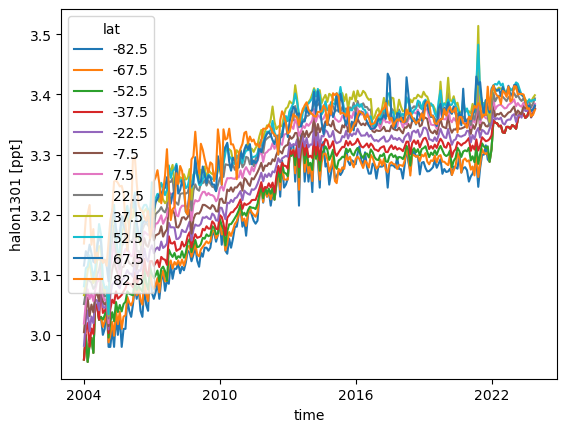

In [11]:
lon_mean = interpolated_spatial_nan_free.mean(dim="lon")
lon_mean.plot(hue="lat")  # type: ignore

### Global-, annual-mean

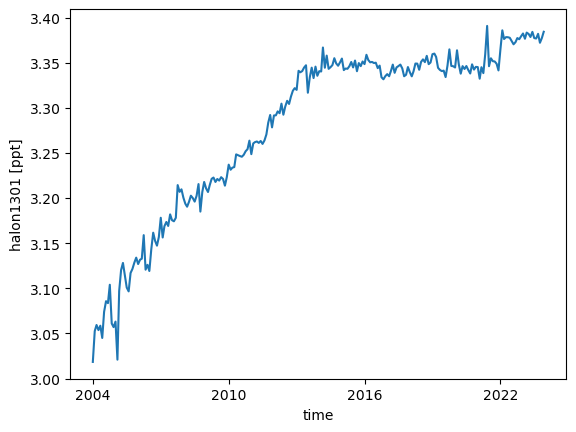

In [12]:
global_mean = local.xarray_space.calculate_global_mean_from_lon_mean(lon_mean)
global_mean.plot()  # type: ignore

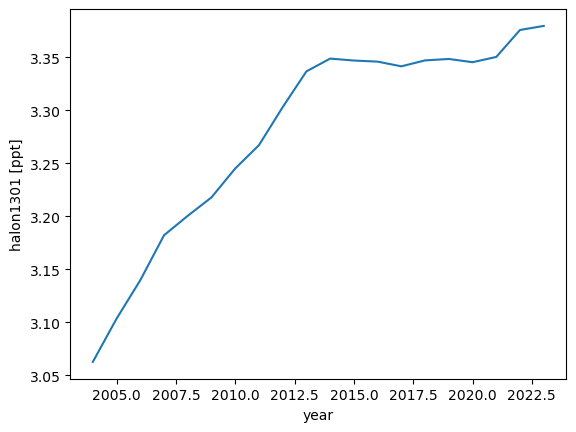

In [13]:
global_annual_mean = global_mean.groupby("time.year").mean()
global_annual_mean.plot()  # type: ignore

### Latitudinal gradient

In [14]:
(
    lat_residuals_annual_mean,
    lat_gradient_full_eofs_pcs,
) = local.latitudinal_gradient.calculate_eofs_pcs(lon_mean, global_mean)
lat_gradient_full_eofs_pcs

<xarray.Dataset> Size: 3kB
Dimensions:               (lat: 12, eof: 12, year: 20)
Coordinates:
  * lat                   (lat) float64 96B -82.5 -67.5 -52.5 ... 52.5 67.5 82.5
  * eof                   (eof) int64 96B 0 1 2 3 4 5 6 7 8 9 10 11
  * year                  (year) int64 160B 2004 2005 2006 ... 2021 2022 2023
Data variables:
    eofs                  (lat, eof) float64 1kB [ppt] 0.4674 0.2475 ... 0.05329
    principal-components  (year, eof) float64 2kB [] -0.1689 ... -2.335e-16

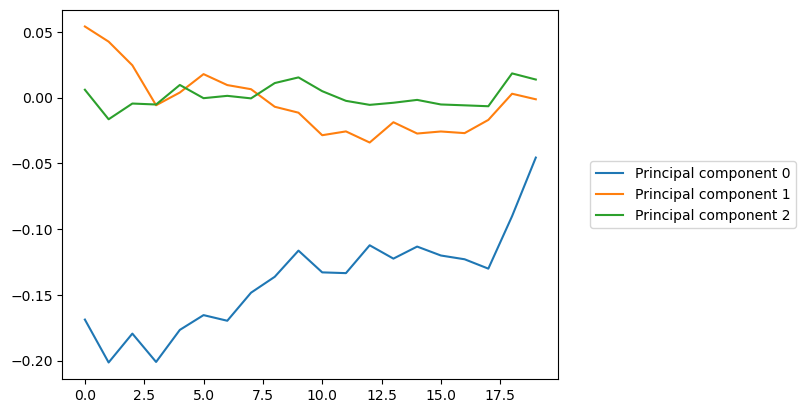

In [15]:
fig, ax = plt.subplots()
n_eofs_to_show = 3

for i in range(n_eofs_to_show):
    ax.plot(
        lat_gradient_full_eofs_pcs["principal-components"].sel(eof=i).data.m,
        label=f"Principal component {i}",
    )

ax.legend(loc="center left", bbox_to_anchor=(1.05, 0.5))

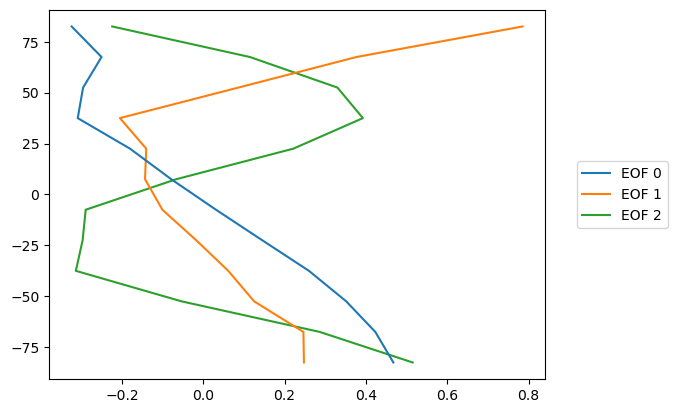

In [16]:
fig, ax = plt.subplots()

for i in range(3):
    ax.plot(
        lat_gradient_full_eofs_pcs["eofs"].sel(eof=i).data.m,
        lat_gradient_full_eofs_pcs["lat"].data,
        label=f"EOF {i}",
        zorder=2 - i / 10,
    )

ax.legend(loc="center left", bbox_to_anchor=(1.05, 0.5))

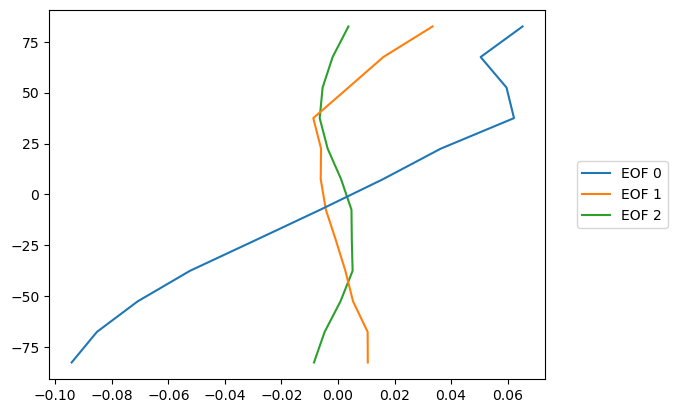

In [17]:
fig, ax = plt.subplots()

for i in range(3):
    ax.plot(
        lat_gradient_full_eofs_pcs["principal-components"].sel(eof=i).isel(year=1)
        @ lat_gradient_full_eofs_pcs["eofs"].sel(eof=i),
        lat_gradient_full_eofs_pcs["lat"],
        label=f"EOF {i}",
        zorder=2 - i / 10,
    )

ax.legend(loc="center left", bbox_to_anchor=(1.05, 0.5))

In [18]:
lat_gradient_eofs_pcs = lat_gradient_full_eofs_pcs.sel(eof=range(config_step.lat_gradient_n_eofs_to_use))
lat_gradient_eofs_pcs

Magnitude,[[0.4674346053514906] [0.4231224891982643] [0.3516242864505123] [0.25984086398226697] [0.14514266276084595] [0.031195882922963523] [-0.07898088251205282] [-0.1803594789324467] [-0.3089300513372474] [-0.2957629914904167] [-0.2503476892281462] [-0.323914725002421]]
Units,ppt
Magnitude,[[-0.16887036840418693] [-0.20150145994630497] [-0.17953277095677536] [-0.20110722718452864] [-0.17671949759194744] [-0.1654708100955942] [-0.16975744531530393] [-0.14841780519575995] [-0.1363115696044332] [-0.11640486754862374] [-0.13295440147392926] [-0.13353166030725924] [-0.11234070302092508] [-0.1224918022079645] [-0.11332498701464717] [-0.12011836367629478] [-0.1229896457889393] [-0.13011703697667565] [-0.09020065670738552] [-0.045627705905252613]]
Units,dimensionless


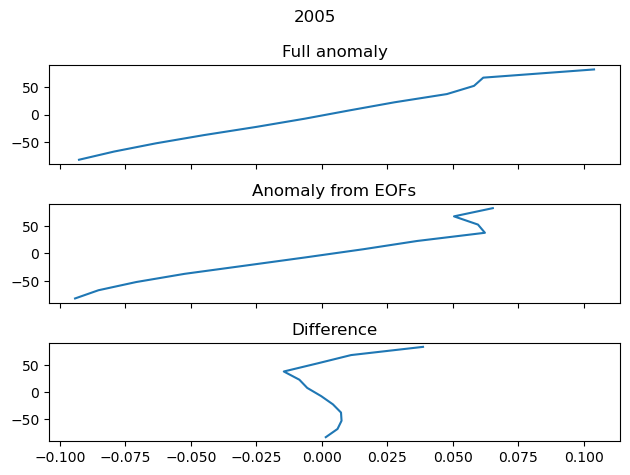

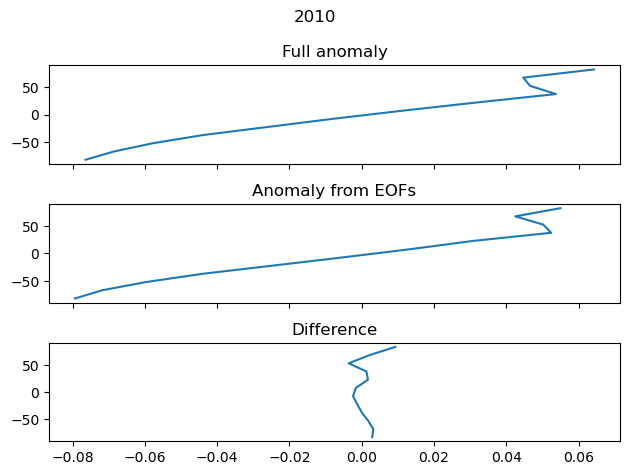

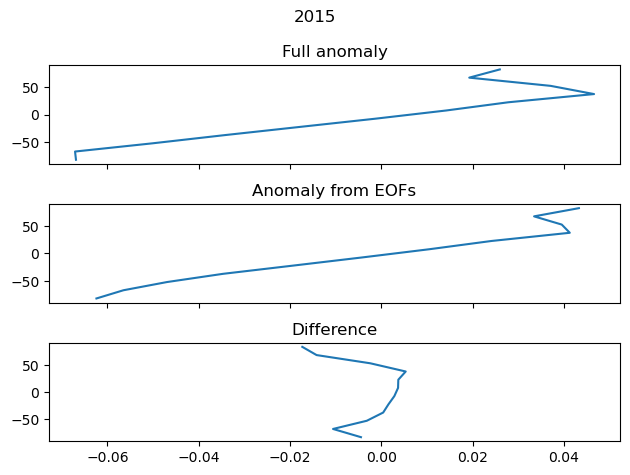

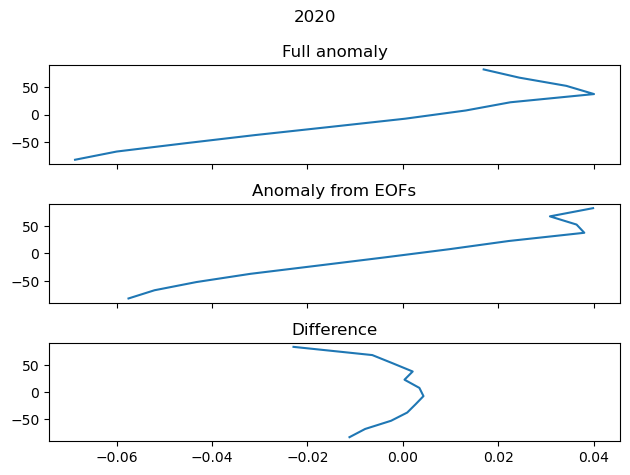

In [19]:
latitudinal_anomaly_from_eofs = lat_gradient_eofs_pcs["principal-components"] @ lat_gradient_eofs_pcs["eofs"]

for year in latitudinal_anomaly_from_eofs["year"]:
    if year % 5:
        continue

    fig, axes = plt.subplots(nrows=3, sharex=True, sharey=True)
    if isinstance(axes, matplotlib.axes.Axes):
        raise TypeError(type(axes))

    selected = lat_residuals_annual_mean.sel(year=year)
    axes[0].plot(selected.data.m, lat_residuals_annual_mean.lat)
    axes[0].set_title("Full anomaly")

    selected_eofs = latitudinal_anomaly_from_eofs.sel(year=year)
    axes[1].plot(selected_eofs.data.m, latitudinal_anomaly_from_eofs.lat)
    axes[1].set_title("Anomaly from EOFs")

    axes[2].plot(selected.data.m - selected_eofs.data.m, lat_residuals_annual_mean.lat)
    axes[2].set_title("Difference")

    axes[0].set_ylim([-90, 90])

    plt.suptitle(str(int(year)))
    plt.tight_layout()
    plt.show()

### Seasonality

In [20]:
(
    seasonality,
    relative_seasonality,
    lon_mean_ym_monthly_anomalies,
) = local.seasonality.calculate_seasonality(
    lon_mean=lon_mean,
    global_mean=global_mean,
)

/Users/znicholls/Documents/repos/CMIP-GHG-Concentration-Generation/src/local/seasonality.py:29: UserWarning: The `squeeze` kwarg to GroupBy is being removed.Pass .groupby(..., squeeze=False) to disable squeezing, which is the new default, and to silence this warning.
  lon_mean_ym_annual_mean_monthly = lon_mean_ym_annual_mean.groupby("lat", squeeze=True).apply(  # type: ignore
/Users/znicholls/Documents/repos/CMIP-GHG-Concentration-Generation/.pixi/envs/all-dev/lib/python3.11/importlib/__init__.py:126: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  return _bootstrap._gcd_import(name[level:], package, level)


Calculating output values:   0%|                                                                                                                                                                                      | 0/240 [00:00<?, ?it/s]

Calculating output values: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 240/240 [00:00<00:00, 17432.99it/s]


/Users/znicholls/Documents/repos/CMIP-GHG-Concentration-Generation/src/local/seasonality.py:29: UserWarning: The `squeeze` kwarg to GroupBy is being removed.Pass .groupby(..., squeeze=False) to disable squeezing, which is the new default, and to silence this warning.
  lon_mean_ym_annual_mean_monthly = lon_mean_ym_annual_mean.groupby("lat", squeeze=True).apply(  # type: ignore


Calculating output values:   0%|                                                                                                                                                                                      | 0/240 [00:00<?, ?it/s]

...

Calculating output values:   0%|                                                                                                                                                                                      | 0/240 [00:00<?, ?it/s]

Calculating output values: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 240/240 [00:00<00:00, 19959.81it/s]


/Users/znicholls/Documents/repos/CMIP-GHG-Concentration-Generation/src/local/seasonality.py:29: UserWarning: The `squeeze` kwarg to GroupBy is being removed.Pass .groupby(..., squeeze=False) to disable squeezing, which is the new default, and to silence this warning.
  lon_mean_ym_annual_mean_monthly = lon_mean_ym_annual_mean.groupby("lat", squeeze=True).apply(  # type: ignore


Calculating output values:   0%|                                                                                                                                                                                      | 0/240 [00:00<?, ?it/s]

Calculating output values: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 240/240 [00:00<00:00, 20114.15it/s]

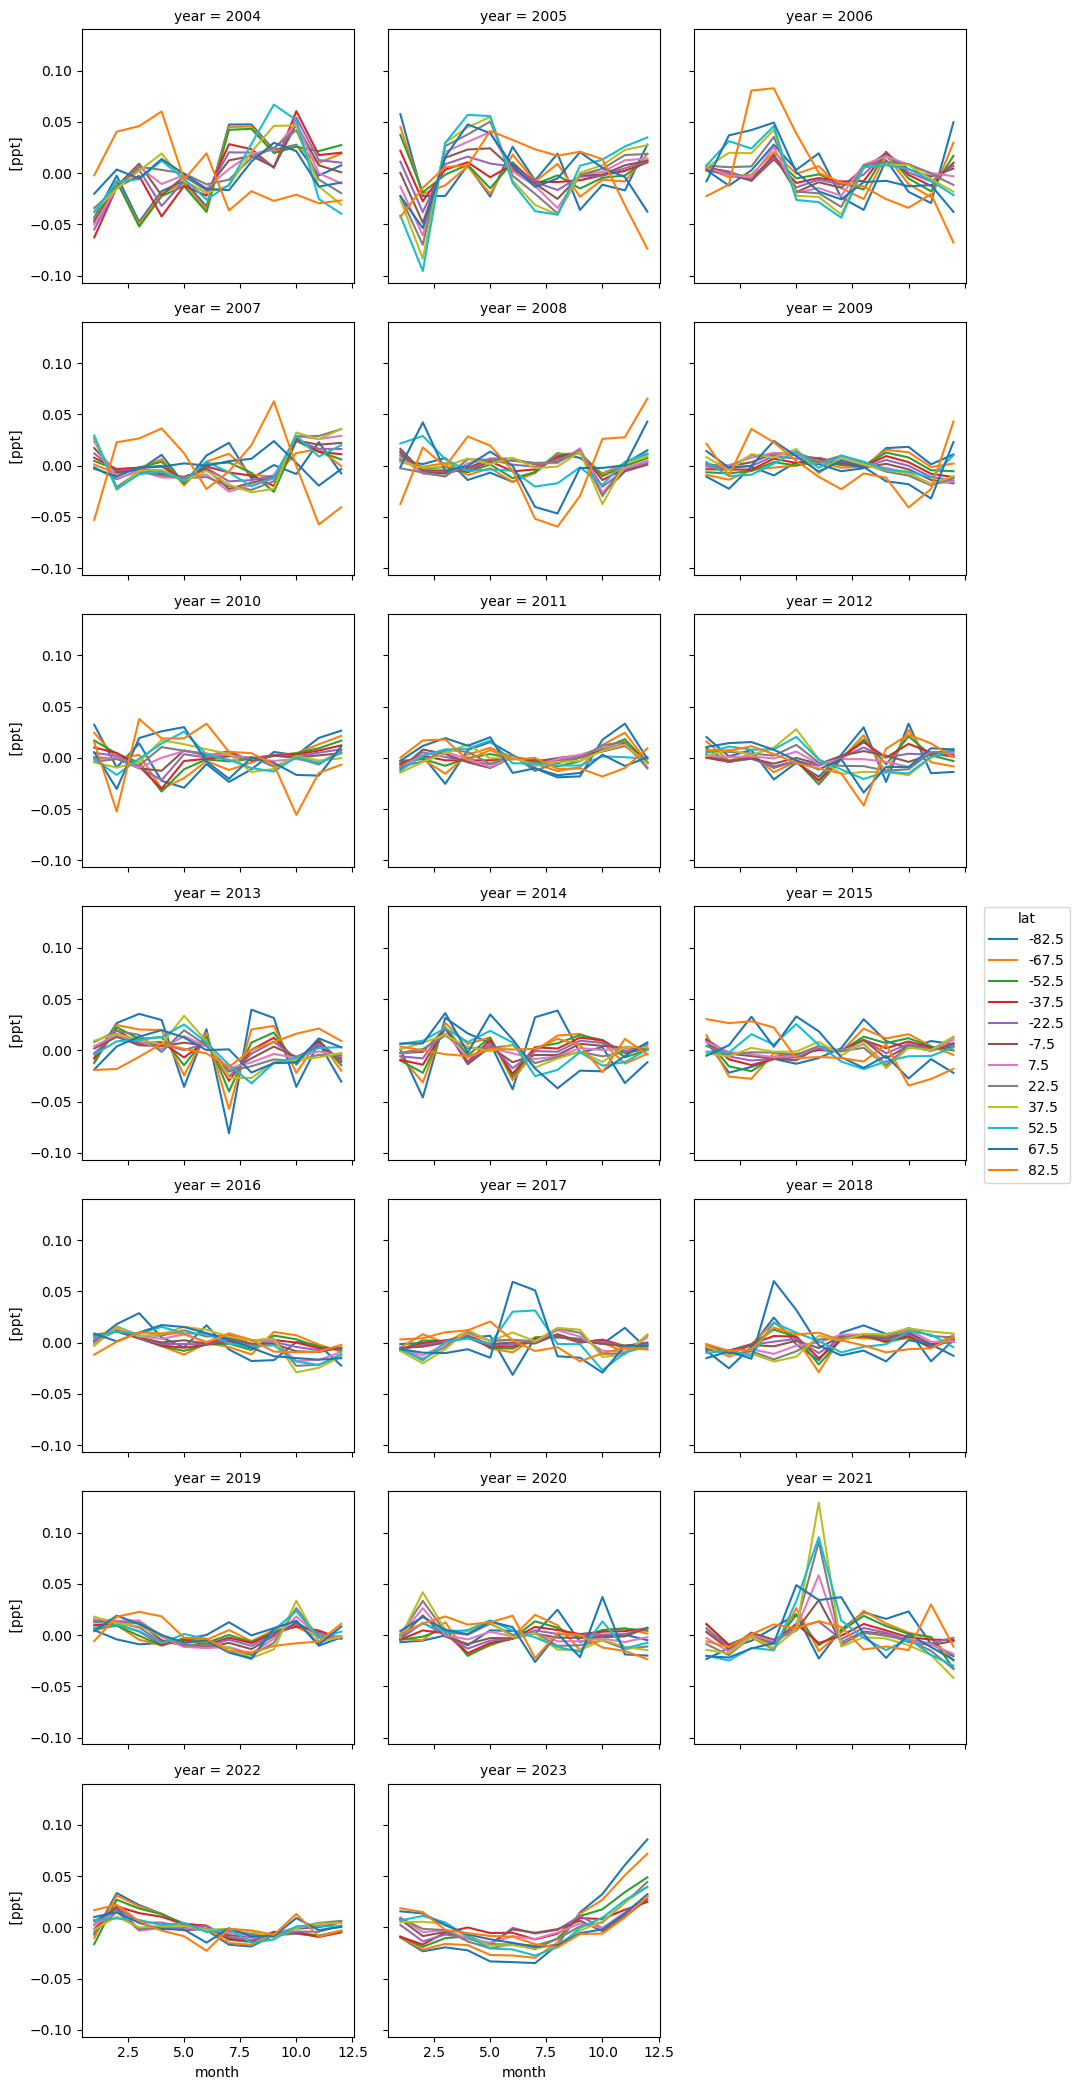

In [21]:
lon_mean_ym_monthly_anomalies.plot.line(hue="lat", col="year", col_wrap=3)

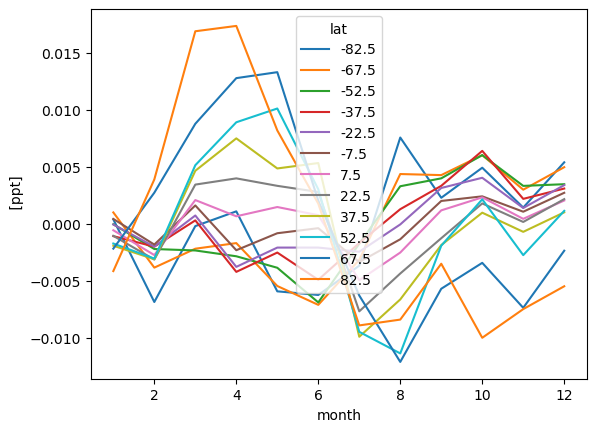

In [22]:
seasonality.plot.line(hue="lat")

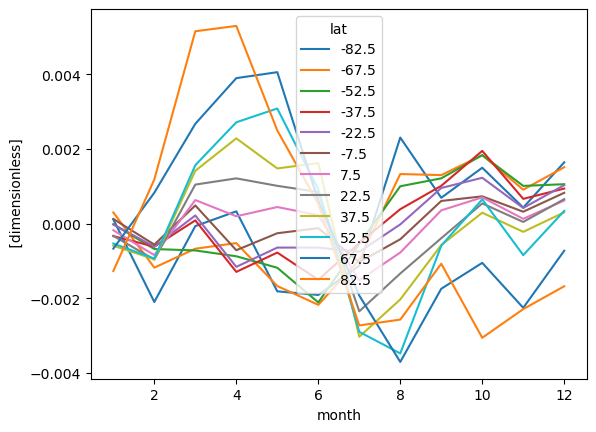

In [23]:
relative_seasonality.plot.line(hue="lat")

### Save

In [24]:
config_step.observational_network_global_annual_mean_file.parent.mkdir(exist_ok=True, parents=True)
global_annual_mean.pint.dequantify().to_netcdf(config_step.observational_network_global_annual_mean_file)
global_annual_mean

Magnitude,[3.062715702989778 3.103512752193278 3.139809487211064 3.1822203563175187 3.2005680975561526 3.217961197862657 3.2452074886108018 3.2672354757125586 3.3030852168301514 3.3368518239009304 3.3489105603306655 3.3470933670657854 3.346060703140339 3.3416160351964908 3.347212288790752 3.348568244000051 3.3455067350472327 3.3504638137563085 3.3759129553301346 3.379743509948636]
Units,ppt


In [25]:
config_step.observational_network_latitudinal_gradient_eofs_file.parent.mkdir(exist_ok=True, parents=True)
lat_gradient_eofs_pcs.pint.dequantify().to_netcdf(
    config_step.observational_network_latitudinal_gradient_eofs_file
)
lat_gradient_eofs_pcs

Magnitude,[[0.4674346053514906] [0.4231224891982643] [0.3516242864505123] [0.25984086398226697] [0.14514266276084595] [0.031195882922963523] [-0.07898088251205282] [-0.1803594789324467] [-0.3089300513372474] [-0.2957629914904167] [-0.2503476892281462] [-0.323914725002421]]
Units,ppt
Magnitude,[[-0.16887036840418693] [-0.20150145994630497] [-0.17953277095677536] [-0.20110722718452864] [-0.17671949759194744] [-0.1654708100955942] [-0.16975744531530393] [-0.14841780519575995] [-0.1363115696044332] [-0.11640486754862374] [-0.13295440147392926] [-0.13353166030725924] [-0.11234070302092508] [-0.1224918022079645] [-0.11332498701464717] [-0.12011836367629478] [-0.1229896457889393] [-0.13011703697667565] [-0.09020065670738552] [-0.045627705905252613]]
Units,dimensionless


In [26]:
# Use relative seasonality
config_step.observational_network_seasonality_file.parent.mkdir(exist_ok=True, parents=True)
relative_seasonality.pint.dequantify().to_netcdf(config_step.observational_network_seasonality_file)
relative_seasonality

Magnitude,[[0.0001141578898728948 -0.002097982675060802 -6.588166781814151e-05 0.0003290996988054328 -0.001812563359608381 -0.0019095498859731774 -0.0011249562290871846 0.0023055825088276823 0.0006926254576172677 0.0014971515030824194 0.0004302901576175918 0.0016420610192627984] [0.0003002674815399915 -0.001177431382745088 -0.0006711617011707018 -0.0005210462684191531 -0.0016696284147082077 -0.002174468443162848 -0.0009691943754180975 0.0013283782666130765 0.0012995575570308978 0.0018338907336030335 0.0009090920832601961 0.001511772665009037] [-1.636844128161247e-05 -0.000679457847326281 -0.0007181737096707684 -0.0008735632537222066 -0.0011814542215352194 -0.0021093111016981876 -0.0005374219895869715 0.0010012263695655741 0.00121284463850953 0.0018349806510335011 0.0010107193658826365 0.0010559973790409019] [-0.0003343242207802298 -0.0006160499997492459 8.73882437881719e-05 -0.0012912607401234049 -0.0007743500918440357 -0.0015037028490195686 -0.0005179235796955515 0.0003868131684197136 0.0010123025095521558 0.0019479820038601219 0.0006634583276412558 0.0009396741082892073] [-2.347838257806362e-05 -0.0006149738229782153 0.0002179504164530284 -0.0011570948564611045 -0.0006412004357854464 -0.0006407707369630764 -0.0007525725323738713 -2.0871629151002272e-05 0.0009548491892737872 0.00122811538611952 0.00041842795258802986 0.0010316290483428094] [0.00012625532966525715 -0.0005604306863993761 0.0004870255864128371 -0.0007115370445889204 -0.00025690026530542814 -0.00012147505196645753 -0.0010281895681123873 -0.0004183126200703296 0.0006073128980131466 0.0007308934095405625 0.00031932730826158976 0.0008260406376901207] [-0.00017704695788820217 -0.0008416812229816341 0.0006312276110050022 0.0001970561826787123 0.0004450301869328625 0.0002268623473596306 -0.00151486983908596 -0.0007739003613280132 0.0003557366471871818 0.0007035358017546787 0.00012846551255176993 0.0006195971820663819] [-0.00032692245129009584 -0.000961224471330586 0.0010454574136878874 0.001212131975424726 0.0010121281773991175 0.0008480657202893643 -0.002347272188012379 -0.00133503858885043 -0.0003901770442026917 0.0005410625462525662 4.52353675268707e-05 0.0006565727687087481] [-0.0005904940016724716 -0.0009535421924023543 0.0014153139122366559 0.002283031149102182 0.0014776987442816406 0.0016224794948241476 -0.003028343361147395 -0.00202930631459675 -0.0005735708748608084 0.0002932164138506842 -0.00021952711793599917 0.0003030624637347561] [-0.0005322538029794767 -0.0009360233309289418 0.001564605288603197 0.0027141851963765847 0.003082682017778876 0.0009193230128646041 -0.0028972596283776066 -0.0034748029949982304 -0.0005902839940212045 0.000651208973375112 -0.0008432482921278652 0.0003418890424784963] [-0.0006692207472219499 0.0008282976786980347 0.0026734994293248922 0.0038959692024309427 0.00405552328553593 0.0006145174914189656 -0.0019244932139629595 -0.0037024362598354894 -0.0017433222814383508 -0.0010498839759926024 -0.0022538881443452323 -0.0007245428679811386] [-0.0012703155788808468 0.0011838010976313773 0.0051510227053511125 0.005293925611157932 0.0024957581456913733 0.0005342717771795392 -0.002724999128234037 -0.0025691082801198037 -0.0010735905081452313 -0.0030558599310576964 -0.0022883006213697257 -0.001676584395336061]]
Units,dimensionless
